In [1]:
import sys
from pathlib import Path

import pandas as pd
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# da notebook vidi src/ (repo root je parent od notebooks/)
PROJECT_ROOT = Path.cwd().parents[0]
sys.path.append(str(PROJECT_ROOT))

from src.io import csv_to_adata

from src.qc import annotate_qc_genes, compute_qc_metrics, flag_outliers  

from src.preprocess import store_raw_counts, normalize_and_log, select_hvgs


DATA_RAW = PROJECT_ROOT / "data" / "raw"

## Učitavanje, preprocesiranje i vizualizacija

In [2]:
osoba1_adata = csv_to_adata(DATA_RAW / "GSM2230757_human1_umifm_counts.csv.gz")
osoba2_adata = csv_to_adata(DATA_RAW / "GSM2230758_human2_umifm_counts.csv.gz")
osoba3_adata = csv_to_adata(DATA_RAW / "GSM2230759_human3_umifm_counts.csv.gz")
osoba4_adata = csv_to_adata(DATA_RAW / "GSM2230760_human4_umifm_counts.csv.gz")

# brza provera dimenzija
for i, ad in enumerate([osoba1_adata, osoba2_adata, osoba3_adata, osoba4_adata], start=1):
    print(f"osoba{i}: n_cells={ad.n_obs}, n_genes={ad.n_vars}")

/usr/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/usr/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/usr/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


osoba1: n_cells=1937, n_genes=20125
osoba2: n_cells=1724, n_genes=20125
osoba3: n_cells=3605, n_genes=20125
osoba4: n_cells=1303, n_genes=20125


/usr/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [4]:
for i, ad in enumerate([osoba1_adata, osoba2_adata, osoba3_adata, osoba4_adata], start=1):
    annotate_qc_genes(ad)
    compute_qc_metrics(ad)
    flag_outliers(ad, nmads=5, key="outlier")
    print(f"osoba{i} outliers:", ad.obs["outlier"].value_counts().to_dict())

osoba1 outliers: {False: 1936, True: 1}
osoba2 outliers: {False: 1723, True: 1}
osoba3 outliers: {False: 3598, True: 7}
osoba4 outliers: {False: 1298, True: 5}


In [5]:
adata = sc.concat(
    [osoba1_adata, osoba2_adata, osoba3_adata, osoba4_adata],
    label="batch",
    keys=["H1", "H2", "H3", "H4"]
)

/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [6]:
store_raw_counts(adata)
normalize_and_log(adata)
select_hvgs(adata)
print("Broj HVG-ova:", adata.var["hvg_flag"].sum())

/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
 

Broj HVG-ova: 4000


/tmp/ipykernel_173267/2524770312.py:1: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  sc.pp.pca(adata, svd_solver="arpack", use_highly_variable=True)


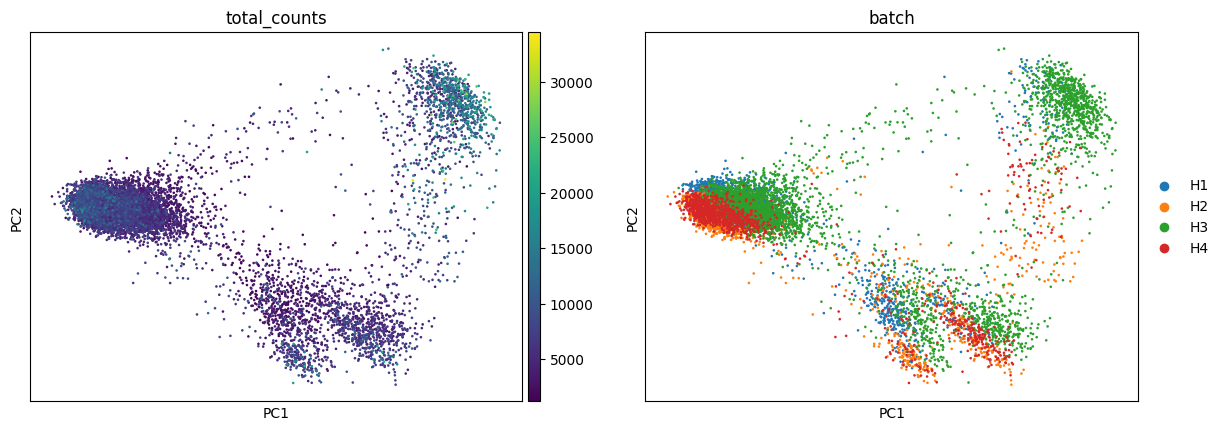

In [7]:
sc.pp.pca(adata, svd_solver="arpack", use_highly_variable=True)
sc.pl.pca_scatter(adata, color=["total_counts", "batch"])

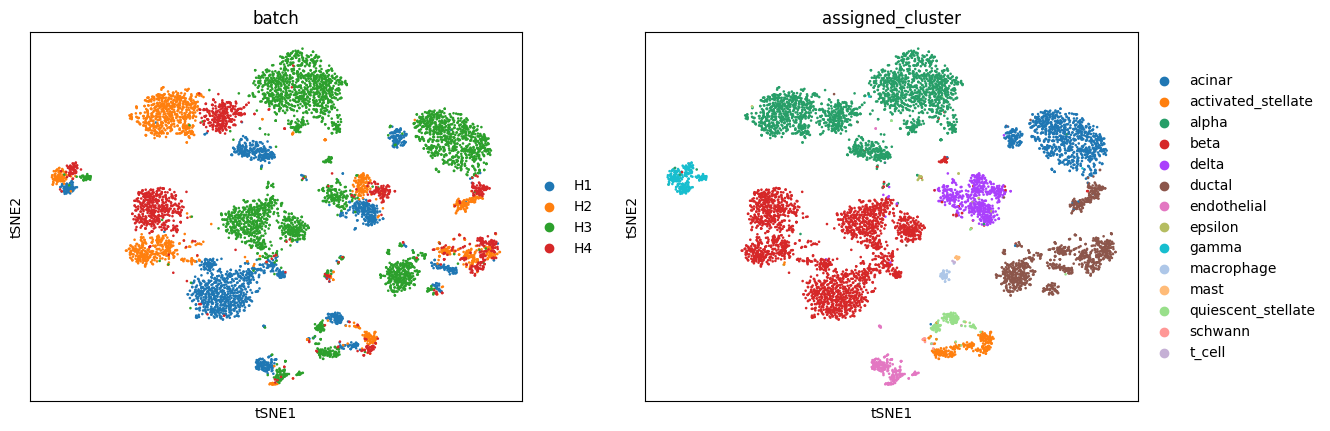

In [ ]:
sc.tl.tsne(adata, use_rep="X_pca")
sc.pl.tsne(adata, color=["batch", "assigned_cluster"])

/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


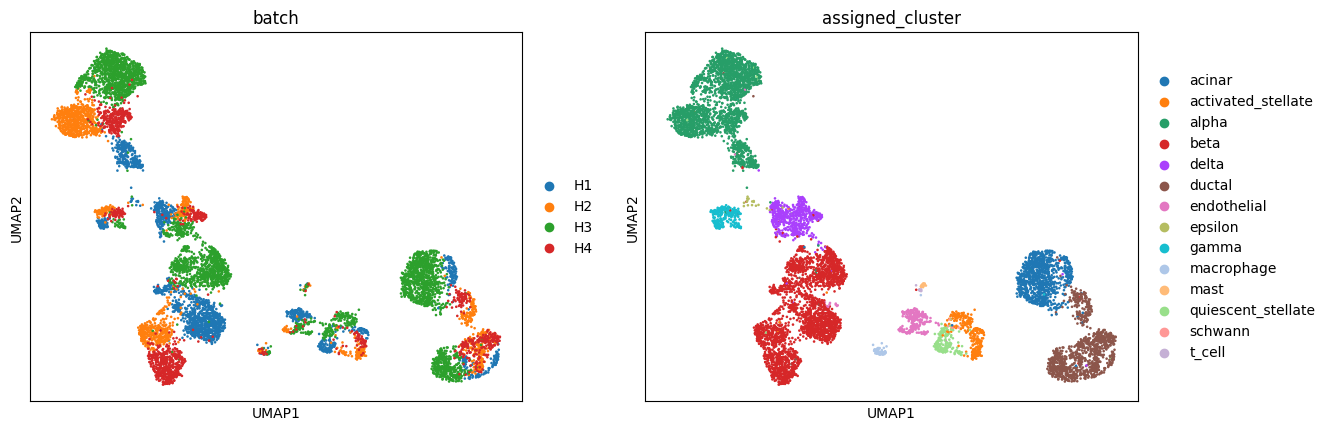

In [ ]:
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.pl.umap(adata, color=["batch", "assigned_cluster"])

## Pravila pridruzivanja

In [9]:
from src.rules import RulesConfig, run_rules_pipeline, rules_to_edge_list

cfg = RulesConfig(
    n_top_genes=120,
    groupby="assigned_cluster",   
    min_frac_in_group=0.10,
    min_support=0.20,           
    max_len=2,
    min_threshold=1.0,
)

out = run_rules_pipeline(adata, cfg)
out["rules"].head(10)

edges = rules_to_edge_list(out["rules"])
edges

/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
 

,gene1,gene2,support,confidence,lift
0,CTGF,TAGLN,0.214286,1.000000,4.666667
1,TAGLN,CTGF,0.214286,1.000000,4.666667
2,TYROBP,RGS1,0.214286,1.000000,4.666667
3,RGS1,TYROBP,0.214286,1.000000,4.666667
4,RGS1,CD52,0.214286,1.000000,4.666667
...,...,...,...,...,...
627,HMOX1,IGFBP5,0.214286,0.500000,1.000000
628,SRGN,IGFBP5,0.214286,0.500000,1.000000
629,IGFBP5,PLAU,0.214286,0.428571,1.000000
630,IGFBP5,HMOX1,0.214286,0.428571,1.000000


In [11]:
rules = out["rules"].copy()

# tipični pragovi
MIN_SUPPORT = 0.10
MIN_CONF    = 0.70
MIN_LIFT    = 1.50

rules_f = rules[
    (rules["support"] >= MIN_SUPPORT) &
    (rules["confidence"] >= MIN_CONF) &
    (rules["lift"] >= MIN_LIFT)
].copy()

rules_f = rules_f.sort_values(["lift", "confidence", "support"], ascending=False).reset_index(drop=True)

print("All rules:", len(rules))
print("Filtered rules:", len(rules_f))
rules_f.head(15)

All rules: 632
Filtered rules: 275


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(CTGF),(TAGLN),0.214286,0.214286,0.214286,1.0,4.666667,1.0,0.168367,inf,1.000000,1.00,1.0,1.000
1,(TAGLN),(CTGF),0.214286,0.214286,0.214286,1.0,4.666667,1.0,0.168367,inf,1.000000,1.00,1.0,1.000
2,(TYROBP),(RGS1),0.214286,0.214286,0.214286,1.0,4.666667,1.0,0.168367,inf,1.000000,1.00,1.0,1.000
3,(RGS1),(TYROBP),0.214286,0.214286,0.214286,1.0,4.666667,1.0,0.168367,inf,1.000000,1.00,1.0,1.000
4,(RGS1),(CD52),0.214286,0.214286,0.214286,1.0,4.666667,1.0,0.168367,inf,1.000000,1.00,1.0,1.000
5,(CD52),(RGS1),0.214286,0.214286,0.214286,1.0,4.666667,1.0,0.168367,inf,1.000000,1.00,1.0,1.000
6,(TYROBP),(CD52),0.214286,0.214286,0.214286,1.0,4.666667,1.0,0.168367,inf,1.000000,1.00,1.0,1.000
7,(CD52),(TYROBP),0.214286,0.214286,0.214286,1.0,4.666667,1.0,0.168367,inf,1.000000,1.00,1.0,1.000
8,(SERPINE1),(STC1),0.285714,0.285714,0.285714,1.0,3.500000,1.0,0.204082,inf,1.000000,1.00,1.0,1.000
9,(STC1),(SERPINE1),0.285714,0.285714,0.285714,1.0,3.500000,1.0,0.204082,inf,1.000000,1.00,1.0,1.000


## Klasterovanje

In [ ]:
from src.clustering import cluster_kmeans, cluster_spectral, cluster_gmm
from src.clustering import cluster_hdbscan, cluster_leiden
from src.clustering import compare_clusterings

cluster_kmeans(adata, k=7, random_state=42)
cluster_spectral(adata, k=7, random_state=42)
cluster_gmm(adata, k=7, random_state=42)
cluster_hdbscan(adata, min_cluster_size=50)
cluster_leiden(adata, resolutions=[0.5])

/home/janazivkovic/Documents/Fakultet/Master studije/IP2/src/clustering.py:48: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, key_added=key, resolution=r, random_state=random_state)


In [13]:
keys = [
    "kmeans_cluster",
    "spectral_cluster",
    "hdbscan_cluster",
    "gmm_cluster",
    "leiden_res0_5",
]
results = compare_clusterings(adata, keys)
results

,Model,n_clusters,Silhouette
2,hdbscan_cluster,6,0.348069
0,kmeans_cluster,7,0.303129
1,spectral_cluster,7,0.295393
3,gmm_cluster,7,0.284439
4,leiden_res0_5,14,0.213823


## Klasifikacija

In [ ]:
import importlib
import src.classification as clf
importlib.reload(clf)

from src.classification import cv_compare_models_with_pca
from src.classification import train_random_forest, train_svm, train_xgboost, train_lightgbm, train_naive_bayes

X = adata[:, adata.var["hvg_flag"]].X   
y = adata.obs["assigned_cluster"].astype(str).to_numpy()

trainers = {
    "RandomForest": lambda split: train_random_forest(split, random_state=42),
    "SVM": train_svm,
    "NaiveBayes": train_naive_bayes,
    "XGBoost": lambda split: train_xgboost(split, random_state=42),
    "LightGBM": lambda split: train_lightgbm(split, random_state=42),
}

cv_results = cv_compare_models_with_pca(
    X=X,
    y=y,
    trainers=trainers,
    n_splits=5,
    n_components=50,   
    random_state=42,
)

cv_results

/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/janazivkovic/Documents/Fak

,model,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,n_splits,n_components
1,SVM,0.989380,0.002523,0.955625,0.028579,5,50
4,LightGBM,0.987163,0.003804,0.946239,0.035013,5,50
3,XGBoost,0.987746,0.004425,0.944105,0.040136,5,50
2,NaiveBayes,0.978411,0.003572,0.934086,0.037405,5,50
0,RandomForest,0.985646,0.004436,0.908504,0.053418,5,50
